Final Project CS596

In [ ]:
pip install yfinance

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
cd "/content/drive/MyDrive/Colab Notebooks/Final project/yahoo finance dataset"

In [361]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import os
import torch
import torch.nn as nn
from argparse import Namespace
from copy import deepcopy as dc

In [364]:


def download_and_even_split_stock_data(ticker, start_date, end_date, path):
    # Fetching the stock data
    stock_data = yf.download(ticker, start=start_date, end=end_date)

    # Calculate the index to split the data
    split_index = len(stock_data) // 2

    # Splitting the data into two halves
    train_data = stock_data.iloc[:split_index]
    test_data = stock_data.iloc[split_index:]

    # Paths for saving the datasets
    train_path = os.path.join(path, f'{ticker}_train_data.csv')
    test_path = os.path.join(path, f'{ticker}_test_data.csv')

    # Ensure directory exists
    os.makedirs(os.path.dirname(train_path), exist_ok=True)

    # Saving to CSV
    train_data.to_csv(train_path)
    test_data.to_csv(test_path)

    #return f'Training data saved to {train_path}, Test data saved to {test_path}.'
    return stock_data



def prepare_dataframe_for_lstm(df, n_steps):
    df = dc(df)

    for i in range(1, n_steps+1):
        df[f'Close(t-{i})'] = df['Close'].shift(i)

    df.dropna(inplace=True)

    return df

In [365]:
args=Namespace(ticker_symbol='AAPL',start_date='1997-01-01',end_date='2024-03-01',learning_rate=0.1,batch_size=32,lookback=5,epochs=50,units_hidden=50, units=50,path = '/content/drive/MyDrive/Colab Notebooks/Final project/yahoo finance dataset')


[*********************100%%**********************]  1 of 1 completed


(6835, 6)
(6830, 11)
                Open      High       Low     Close  Adj Close      Volume
Date                                                                     
1997-01-02  0.188616  0.189732  0.185268  0.187500   0.158737   143113600
1997-01-03  0.188616  0.198661  0.187500  0.194196   0.164406   119716800
1997-01-06  0.157366  0.163783  0.154018  0.159598   0.135116  1882832000
1997-01-07  0.161830  0.162946  0.156250  0.156250   0.132281   976931200
1997-01-08  0.162946  0.164063  0.155134  0.157366   0.133226  1100131200
1997-01-09  0.158482  0.159598  0.156250  0.158482   0.134171   446656000
1997-01-10  0.157366  0.162946  0.157366  0.162946   0.137950   353718400
1997-01-13  0.165179  0.165179  0.161830  0.161830   0.137005   305748800
1997-01-14  0.164063  0.164063  0.158482  0.159598   0.135116   255774400
1997-01-15  0.160714  0.160714  0.152902  0.154018   0.130392   433092800
                Open      High       Low     Close  Adj Close     Volume  \
Date           

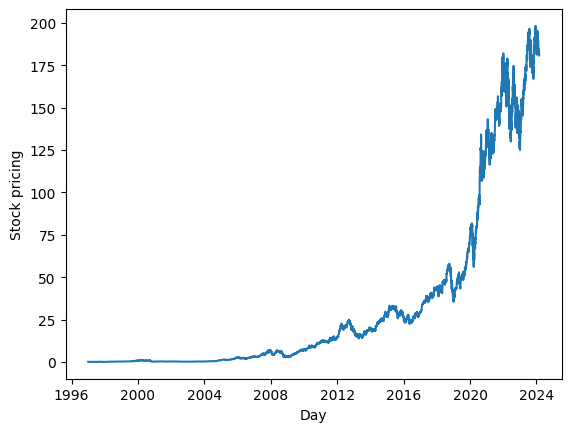

In [367]:
data=download_and_even_split_stock_data(args.ticker_symbol,args.start_date,args.end_date,args.path)
print (data.shape)
plt.plot(data.index,data['Close'])
plt.xlabel('Day')
plt.ylabel('Stock pricing')
shifted_df=prepare_dataframe_for_lstm(data,args.lookback)
shifted_df_as_np = shifted_df.to_numpy()
print (shifted_df.shape)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
shifted_df_as_np = scaler.fit_transform(shifted_df_as_np)
X = shifted_df_as_np[:, 1:]
y = shifted_df_as_np[:, 0]
X = dc(np.flip(X, axis=1))
split_index = int(len(X) * 0.95)
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


X_train = X_train.reshape((-1, args.lookback, 1))
X_test = X_test.reshape((-1, args.lookback, 1))

y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))



X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).float()
print (data.head(10))
print (shifted_df.head())
print (shifted_df.head())

In [384]:

dataset_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final project/yahoo finance dataset/AAPL_train_data.csv')
training_set = dataset_train.iloc[:, 1:2].values

In [385]:

from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
training_set_scaled = sc.fit_transform(training_set)

In [386]:

X_train = []
y_train = []
for i in range(60, 3416):
        X_train.append(training_set_scaled[i-60:i, 0])
        y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [387]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [388]:
!pip install tensorflow

In [389]:
X_train = X_train[:y_train.shape[0]]

In [390]:
#importing the keras librarires and packages
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense

In [391]:
#Initialising the RNN
regressor = Sequential()


In [392]:
regressor.add(LSTM(units = args.units, return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

In [393]:
regressor.add(LSTM(units = args.units, return_sequences = True))
regressor.add(Dropout(0.2))

In [394]:
regressor.add(LSTM(units = args.units))
regressor.add(Dropout(0.2))

In [395]:
# Adding a hidden layer
regressor.add(Dense(units=args.units_hidden, activation='relu'))

In [398]:
regressor.add(Dense(units = 1))

In [400]:
#compiling the RNN
#####regressor.compile(optimizer = 'SGD', loss = 'mean_squared_error')
from keras.optimizers import SGD
learning_rate = args.learning_rate  # Set the learning rate
optimizer = SGD(learning_rate=learning_rate)  # Use SGD optimizer with the specified learning rate
batch_size = args.batch_size  # Set the batch size
regressor.compile(optimizer = optimizer, loss = 'mean_squared_error')

In [401]:

#Fitting the RNN to the training set
epochs = args.epochs  # Set the number of epochs
regressor.fit(X_train, y_train, epochs = args.epochs, batch_size = args.batch_size)




Epoch 1/50
105/105 [==============================] - 17s 103ms/step - loss: 0.0147
Epoch 2/50
105/105 [==============================] - 11s 103ms/step - loss: 0.0037
Epoch 3/50
105/105 [==============================] - 10s 92ms/step - loss: 0.0023
Epoch 4/50
105/105 [==============================] - 12s 110ms/step - loss: 0.0027
Epoch 5/50
105/105 [==============================] - 12s 110ms/step - loss: 0.0024
Epoch 6/50
105/105 [==============================] - 11s 109ms/step - loss: 0.0020
Epoch 7/50
105/105 [==============================] - 9s 89ms/step - loss: 0.0022
Epoch 8/50
105/105 [==============================] - 12s 110ms/step - loss: 0.0017
Epoch 9/50
105/105 [==============================] - 11s 109ms/step - loss: 0.0016
Epoch 10/50
105/105 [==============================] - 11s 110ms/step - loss: 0.0015
Epoch 11/50
105/105 [==============================] - 10s 94ms/step - loss: 0.0018
Epoch 12/50
105/105 [==============================] - 11s 107ms/step - loss: 

In [403]:
#Predictions and visualising the results

dataset_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final project/yahoo finance dataset/AAPL_test_data.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values

In [404]:
#Getting the predicted stock price
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total)- len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)
X_test = []
for i in range(60, 3416):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

105/105 [==============================] - 6s 36ms/step


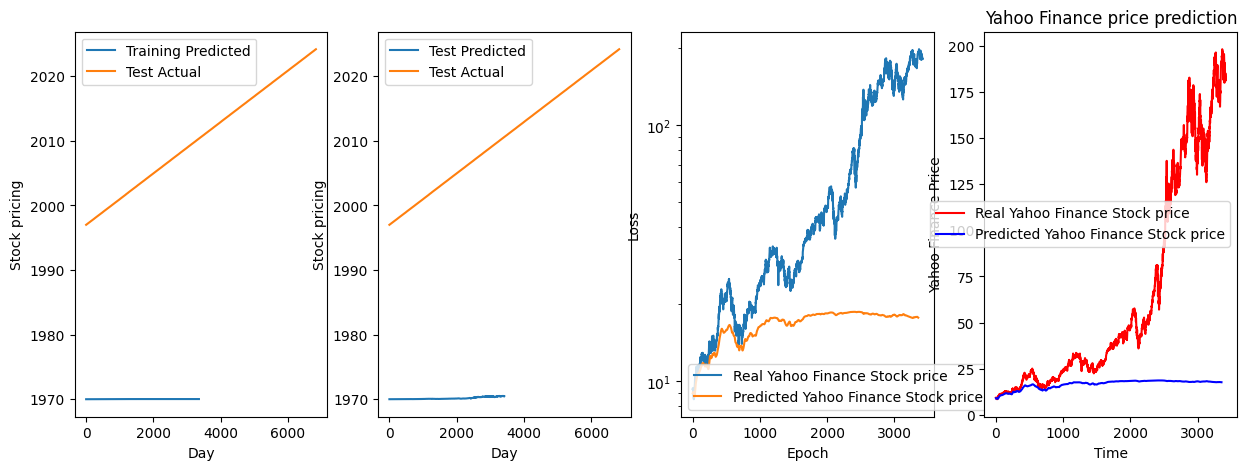

In [405]:
fig,ax=plt.subplots(1,4,figsize=(15,5))
#print (scaler.inverse_transform(y_train))
ax[0].plot(predicted_stock_price,label='Training Predicted')
ax[0].plot(data.index,label='Test Actual')
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Stock pricing')
ax[0].legend()

ax[1].plot(real_stock_price,label='Test Predicted')
ax[1].plot(data.index,label='Test Actual')
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Stock pricing')
ax[1].legend()

ax[2].plot(real_stock_price,label='Real Yahoo Finance Stock price')
ax[2].plot(predicted_stock_price,label='Predicted Yahoo Finance Stock price')
ax[2].set_yscale('log')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('Loss')

#Visualisation the results
ax[3].plot(real_stock_price, color='red', label = 'Real Yahoo Finance Stock price')
ax[3].plot(predicted_stock_price, color = 'blue', label = 'Predicted Yahoo Finance Stock price')
ax[3].set_title('Yahoo Finance price prediction')
ax[3].set_xlabel('Time')
ax[3].set_ylabel('Yahoo Finance Price')
ax[3].legend()



ax[2].legend()

In [311]:
#Visualisation the results
plt.plot(real_stock_price, color='red', label = 'Real Yahoo Finance Stock price')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted Yahoo Finance Stock price')
plt.title('Yahoo Finance price prediction')
plt.xlabel('Time')
plt.ylabel('Yahoo Finance Price')
plt.legend()
plt.show()


IndentationError: expected an indented block after 'with' statement on line 24 (<ipython-input-311-f4ff21210649>, line 27)